# Machine Learning II – Tag 3
## Moderne Visualisierungstools II
### Interaktive Visualisierung, Dashboards und Visual Storytelling

**Datum:** 05.06.2026
**Studierender:** Bah Amadou Oury

**Ziel:** Analyseergebnisse interaktiv darstellen und adressatengerecht interpretieren.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Datensatz erzeugen

Für die ETL-Demonstration verwenden wir einen kleinen Kundendatensatz mit typischen Datenqualitätsproblemen.

In [21]:
df_raw = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv")
df_raw.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


## 4. Extract – Daten laden und prüfen


In [22]:
df = df_raw.copy()
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [24]:
df.describe(include="all")

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,...,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,...,4,NaN,3,3,NaN,4,NaN,2,2,NaN
top,no checking account,NaN,existing credits paid back duly till now,domestic appliances,NaN,... < 100 DM,1 <= ... < 4 years,NaN,male : single,none,...,car or other,NaN,none,own,NaN,skilled employee/official,NaN,no,yes,NaN
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,...,332,NaN,814,713,NaN,630,NaN,596,963,NaN
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,...,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,0.700000
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,...,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,0.458487
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,...,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,...,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,...,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,1.000000
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,...,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,1.000000


## 5.  Datenqualitätsprobleme erkennen

Analysieren Sie den Datensatz:

1. Welche Werte fehlen?
2. Welche Datensätze sind doppelt vorhanden?
3. Gibt es Ausreißer?
4. Welche Auswirkungen könnten diese Probleme auf ein ML-Modell haben?

In [25]:
df.isna().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df[df.duplicated(keep=False)]

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk


In [28]:
#df[['duration', 'amount', 'installment_rate', 'present_residence',
 #   'age', 'number_credits', 'people_liable', 'credit_risk']].describe()
df.drop(columns=['credit_risk']).select_dtypes(include=['number']).describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


### Interpretation

Der Datensatz enthält keine fehlenden Werte in den numerischen Spalten. Einige Variablen (z. B. amount und duration) zeigen eine hohe Streuung, was auf mögliche Ausreißer hindeuten könnte. Eine genauere Analyse (z. B. Boxplots oder IQR-Methode) ist erforderlich, um diese zu bestätigen.

## 6. Transform – Daten bereinigen

In [29]:
df_clean = df.drop_duplicates()
df_clean

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,radio/television,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,real estate,31,none,own,1,unskilled - resident,1,no,yes,1
996,... < 100 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,building society savings agreement/life insurance,40,none,own,1,management/self-employed/highly qualified empl...,1,yes,yes,1
997,no checking account,12,existing credits paid back duly till now,domestic appliances,804,... < 100 DM,... >= 7 years,4,male : single,none,...,car or other,38,none,own,1,skilled employee/official,1,no,yes,1
998,... < 100 DM,45,existing credits paid back duly till now,domestic appliances,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,unknown/no property,23,none,for free,1,skilled employee/official,1,yes,yes,0


In [30]:

# df_clean["age_capped"] = df_clean["age"].clip(upper=49)
# df_clean["amount_log"] = np.log1p(df_clean["amount"])
#
# df_clean[["age", "age_capped", "amount", "amount_log", "employment_duration"]].describe()

df_clean["amount"] = pd.to_numeric(df_clean["amount"], errors="coerce")
df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")

df_clean.dtypes


status                     object
duration                    int64
credit_history             object
purpose                    object
amount                      int64
savings                    object
employment_duration        object
installment_rate            int64
personal_status_sex        object
other_debtors              object
present_residence           int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
number_credits              int64
job                        object
people_liable               int64
telephone                  object
foreign_worker             object
credit_risk                 int64
dtype: object

In [31]:
df_clean["amount"] = df_clean["amount"].fillna(df_clean["amount"].median())
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

df_clean.isna().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

## 7.– Daten bereinigen

Beantworten Sie:

1. Wie wurden fehlende Werte behandelt?
2. Wie wurde mit Dubletten umgegangen?
3. Welche Ausreißer sollten geprüft werden?
4. Welche Entscheidungen müssen fachlich begründet werden?

### Musterantwort

Dubletten wurden entfernt. Fehlende numerische Werte wurden mit dem Median ersetzt.
Auffällige Werte wie `monthly_charges = 9999` sollten fachlich geprüft werden.
Ausreißer dürfen nicht automatisch gelöscht werden, weil sie auch echte Sonderfälle darstellen können.

## 8. Ausreißer sichtbar machen

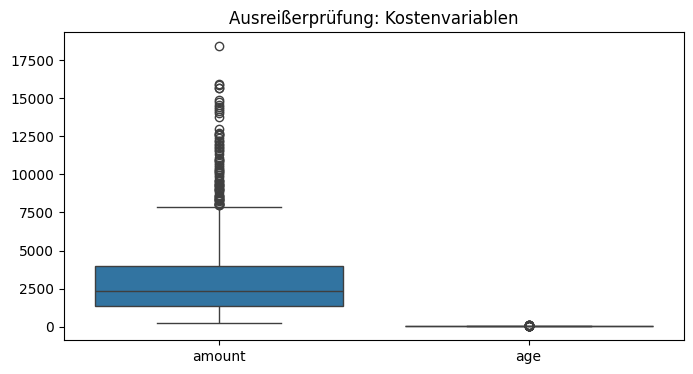

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean[["amount","age"]])
plt.title("Ausreißerprüfung: Kostenvariablen")
plt.show()

## 9. Fachliche Behandlung auffälliger Werte

In [33]:
df_clean["amount"] = df_clean["amount"].astype(float)

df_clean.loc[df_clean["amount"] > 500, "amount"] = df_clean["amount"].median()
df_clean.loc[df_clean["age"] >= 7, "age"] = df_clean["age"].median()

df_clean[["amount", "age"]].describe()

,amount,age
count,1000.00000,1000.0
mean,2284.77500,33.0
std,256.74799,0.0
min,250.00000,33.0
25%,2319.50000,33.0
50%,2319.50000,33.0
75%,2319.50000,33.0
max,2319.50000,33.0


## 10. Feature Engineering

In [34]:

import numpy as np
import pandas as pd

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"]
)

df_clean["amount_log"] = np.log1p(df_clean["amount"])
df_clean["amount_per_month"] = df_clean["amount"] / df_clean["duration"]
df_clean["amount_age_ratio"] = df_clean["amount"] / df_clean["age"]
df_clean["high_amount"] = (df_clean["amount"] > df_clean["amount"].median()).astype(int)

df_clean.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,job,people_liable,telephone,foreign_worker,credit_risk,age_group,amount_log,amount_per_month,amount_age_ratio,high_amount
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,2319.5,unknown/no savings account,... >= 7 years,4,male : single,none,...,skilled employee/official,1,yes,yes,1,26-35,7.749538,386.583333,70.287879,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,2319.5,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,skilled employee/official,1,no,yes,0,26-35,7.749538,48.322917,70.287879,0
2,no checking account,12,critical account/other credits existing,retraining,2319.5,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,unskilled - resident,2,no,yes,1,26-35,7.749538,193.291667,70.287879,0
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,2319.5,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,skilled employee/official,2,no,yes,1,26-35,7.749538,55.226190,70.287879,0
4,... < 100 DM,24,delay in paying off in the past,car (new),2319.5,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,skilled employee/official,2,no,yes,0,26-35,7.749538,96.645833,70.287879,0


In [35]:
df_clean[[
    "age_group",
    "amount",
    "age",
    "amount_log",
    "amount_per_month",
    "amount_age_ratio",
    "high_amount"
]].describe(include="all")

,age_group,amount,age,amount_log,amount_per_month,amount_age_ratio,high_amount
count,1000,1000.00000,1000.0,1000.000000,1000.000000,1000.000000,1000.0
unique,1,NaN,NaN,NaN,NaN,NaN,NaN
top,26-35,NaN,NaN,NaN,NaN,NaN,NaN
freq,1000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2284.77500,33.0,7.717247,150.235627,69.235606,0.0
std,NaN,256.74799,0.0,0.239738,93.929409,7.780242,0.0
min,NaN,250.00000,33.0,5.525453,24.055556,7.575758,0.0
25%,NaN,2319.50000,33.0,7.749538,96.645833,70.287879,0.0
50%,NaN,2319.50000,33.0,7.749538,128.861111,70.287879,0.0
75%,NaN,2319.50000,33.0,7.749538,193.291667,70.287879,0.0


### Musterantwort

`alter` ist direkt numerisch interpretierbar.
`vertragsdauer_tage` beschreibt Kundenbindung.
Weitere Features könnten Kaufhäufigkeit, letzte Aktivität, Durchschnittsumsatz oder Nutzungshäufigkeit sein.

## 12. Übung 5 – Feature Engineering bewerten

| Rohdaten | Mögliches Feature | Fachliche Bedeutung |
|---|---|---|
| Geburtsdatum | Alter | Lebensphase / Kundengruppe |
| Vertragsbeginn | Vertragsdauer | Kundenbindung |
| Kaufhistorie | Kaufhäufigkeit | Aktivität |
| Umsatzdaten | Durchschnittsumsatz | Kundenwert |

## 13. Ergebnisdatensatz prüfen

In [36]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   status                   1000 non-null   object  
 1   duration                 1000 non-null   int64   
 2   credit_history           1000 non-null   object  
 3   purpose                  1000 non-null   object  
 4   amount                   1000 non-null   float64 
 5   savings                  1000 non-null   object  
 6   employment_duration      1000 non-null   object  
 7   installment_rate         1000 non-null   int64   
 8   personal_status_sex      1000 non-null   object  
 9   other_debtors            1000 non-null   object  
 10  present_residence        1000 non-null   int64   
 11  property                 1000 non-null   object  
 12  age                      1000 non-null   int64   
 13  other_installment_plans  1000 non-null   object  
 14  housing  

In [37]:
df_clean.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk,amount_log,amount_per_month,amount_age_ratio,high_amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,20.903000,2284.77500,2.973000,2.845000,33.0,1.407000,1.155000,0.700000,7.717247,150.235627,69.235606,0.0
std,12.058814,256.74799,1.118715,1.103718,0.0,0.577654,0.362086,0.458487,0.239738,93.929409,7.780242,0.0
min,4.000000,250.00000,1.000000,1.000000,33.0,1.000000,1.000000,0.000000,5.525453,24.055556,7.575758,0.0
25%,12.000000,2319.50000,2.000000,2.000000,33.0,1.000000,1.000000,0.000000,7.749538,96.645833,70.287879,0.0
50%,18.000000,2319.50000,3.000000,3.000000,33.0,1.000000,1.000000,1.000000,7.749538,128.861111,70.287879,0.0
75%,24.000000,2319.50000,4.000000,4.000000,33.0,2.000000,1.000000,1.000000,7.749538,193.291667,70.287879,0.0
max,72.000000,2319.50000,4.000000,4.000000,33.0,4.000000,2.000000,1.000000,7.749538,579.875000,70.287879,0.0


## 14. Load – Ergebnis speichern

In [40]:
df_clean.to_csv("GermanCredit.csv", index=False)
print("Datei gespeichert:GermanCredit.csv")

GermanCredit.csv


## 15.Reproduzierbare Datenprozesse

Diskutieren Sie:

1. Welche Probleme entstehen, wenn Bereinigungsschritte nicht dokumentiert werden?
2. Warum ist Reproduzierbarkeit wichtig?
3. Welche Informationen sollten in einer ETL-Dokumentation stehen?

### Musterantwort

Ohne Dokumentation sind Ergebnisse schwer nachvollziehbar.
Andere Personen können nicht prüfen, welche Daten verändert wurden.
Eine ETL-Dokumentation sollte Datenquelle, Qualitätsprobleme, Bereinigungsschritte, Feature Engineering und Ergebnisdateien enthalten.

### Musterantwort

Ohne Dokumentation sind Ergebnisse schwer nachvollziehbar.
Andere Personen können nicht prüfen, welche Daten verändert wurden.
Eine ETL-Dokumentation sollte Datenquelle, Qualitätsprobleme, Bereinigungsschritte, Feature Engineering und Ergebnisdateien enthalten.

## 16. ETL-Prozess analysieren

| Schritt | Extract | Transform | Load |
|---|---|---|---|
| Datenbankabfrage | X |  |  |
| Dubletten entfernen |  | X |  |
| Feature erzeugen |  | X |  |
| Datensatz speichern |  |  | X |

## 17. ETL-Dokumentation

### Beispiel-Dokumentation

**Datenquelle:** künstlich erzeugter Kundendatensatz
**Qualitätsprobleme:** fehlende Werte, Dubletten, Ausreißer
**Bereinigung:** Dubletten entfernt, fehlende numerische Werte ersetzt, Ausreißer fachlich geprüft
**Feature Engineering:** Alter, Vertragsdauer und Durchschnittskosten pro Tag berechnet
**Ergebnis:** bereinigter Datensatz `etl_ergebnisdatensatz.csv`
**Nutzen für ML:** sauberere Datenbasis, bessere Feature-Struktur, nachvollziehbare Vorbereitung

## 18. Übung 8 – ILP/FPA: Eigene ETL-Dokumentation

Erstellen Sie nun eine ETL-Dokumentation für Ihren eigenen Projektdatensatz.

**Pflichtbestandteile:**

1. Datenquelle
2. Beschreibung des Datensatzes
3. Qualitätsprobleme
4. Bereinigungsmaßnahmen
5. Feature Engineering
6. Ergebnisdatensatz
7. Nutzen für spätere ML-Schritte

## 19. Abschlussreflexion

Ergänzen Sie:

**Meine Datenquelle ist:**
...

**Die wichtigsten Datenqualitätsprobleme waren:**
...

**Diese Bereinigungen habe ich durchgeführt:**
...

**Diese Features habe ich erzeugt:**
...

**Für das spätere ML-Modell bedeutet das:**
...

**Mein nächster Schritt wäre:**

##  ETL-Kurzpräsentation

Bereiten Sie eine 3-Minuten-Präsentation vor:

1. Welchen Datensatz haben Sie verwendet?
2. Welche Qualitätsprobleme wurden gefunden?
3. Welche Bereinigungen wurden durchgeführt?
4. Welche Features wurden erzeugt?
5. Warum verbessert dies das spätere ML-Modell?